Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
from this we can gather there is 1 HDU in this file, which has an index of 0, contained in  PrimaryHDU, this has a numbertype of int16(16-bit integer)

First 5 keys: ['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2']
BITPIX: 16
This does in fact correspond with the 16-bit integer found in the previous question.

The array has a shape: (530, 530), which corresponds with question 1
It has a dtype of: >i2
NAXIS1 = 530
NAXIS2 = 530
These values are also in correspondence with the first question
The dtype = >i2
This yields >i2, which is the same as saying its a 16-bit integer, thus corresponding

Minimum = 1507
Maximum = 15752
Mean = 4795.924268422927
Standard deviation = 1848.2526085366376
Median = 4102.0
Mode = ModeResult(mode=3551, count=876)


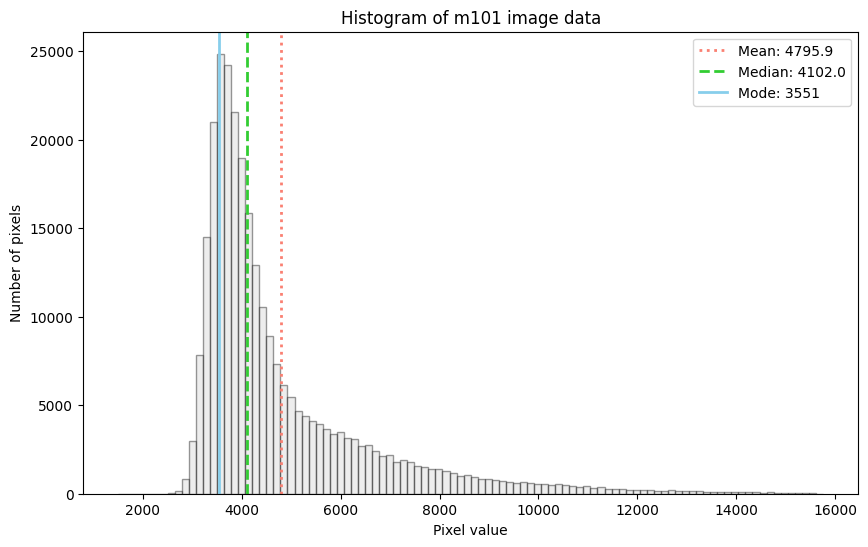

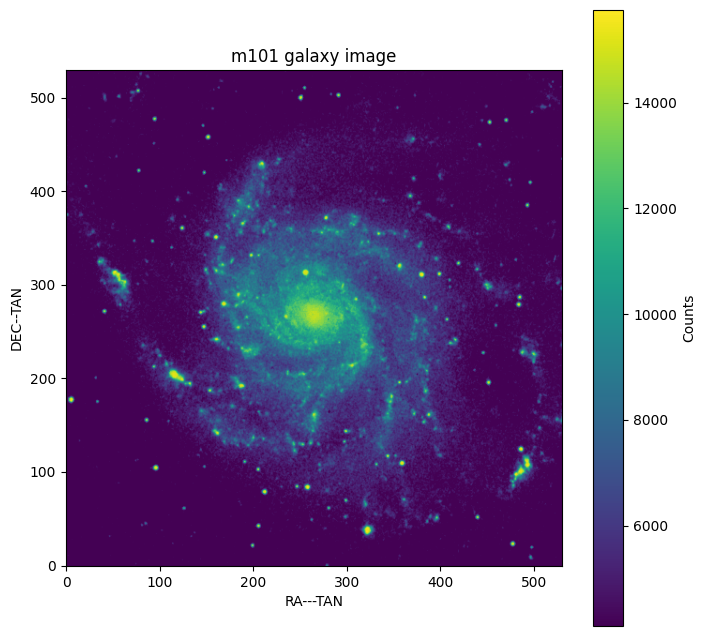

Created file 'm101_float.fits'


In [4]:
#Question 6.1
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
import warnings
from astropy.utils.exceptions import AstropyUserWarning

#2
hdul = fits.open('m101.fits')
hdul.info()
print('from this we can gather there is 2 HDU in this file, which has an index of 0, contained in  PrimaryHDU, this has a numbertype of int16(16-bit integer)')
print()
#3
header = hdul[0].header
print(f"First 5 keys: {list(header.keys())[:5]}")
print(f"BITPIX: {header['BITPIX']}")
print('This does in fact correspond with the 16-bit integer found in the previous question.')
print()
#4
dat = hdul[0].data
print(f'The array has a shape: {dat.shape}, which corresponds with question 1')
print(f'It has a dtype of: {dat.dtype}')
print(f"NAXIS1 = {header['NAXIS1']}")
print(f"NAXIS2 = {header['NAXIS2']}")
print('These values are also in correspondence with the first question')
print(f"The dtype = {dat.dtype}")
print('This yields >i2, which is the same as saying its a 16-bit integer, thus corresponding')
print()
#5
flat_dat = dat.flatten()
print(f"Minimum = {np.min(flat_dat)}")
print(f"Maximum = {np.max(flat_dat)}")
print(f"Mean = {np.mean(flat_dat)}")
print(f"Standard deviation = {np.std(flat_dat)}")
print(f"Median = {np.median(flat_dat)}")
print(f"Mode = {stats.mode(flat_dat)}")
#6
data_mean = np.mean(flat_dat)
data_median = np.median(flat_dat)
data_mode = stats.mode(flat_dat, keepdims=True).mode[0]
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.hist(flat_dat, bins=100, color='lightgray', edgecolor='black', alpha=0.4)
ax1.axvline(data_mean, color='salmon', linestyle=':', linewidth=2, label=f'Mean: {data_mean:.1f}')
ax1.axvline(data_median, color='limegreen', linestyle='--', linewidth=2, label=f'Median: {data_median:.1f}')
ax1.axvline(data_mode, color='skyblue', linestyle='-', linewidth=2, label=f'Mode: {data_mode}')
ax1.set_title("Histogram of m101 image data")
ax1.set_xlabel("Pixel value")
ax1.set_ylabel("Number of pixels")
ax1.legend()
plt.show()
#7
dat_float = np.asarray(dat, dtype=float)
fig, ax2 = plt.subplots(figsize=(8, 8))
im = ax2.imshow(dat_float, cmap='viridis', origin='lower', vmin=data_median)
ax2.set_xlabel(header.get('CTYPE1', 'CTYPE1'))
ax2.set_ylabel(header.get('CTYPE2', 'CTYPE2'))
cbar = plt.colorbar(im)
cbar.set_label('Counts')
ax2.set_title("m101 galaxy image")
plt.show()
#8
header['BUNIT'] = 'Counts'
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=AstropyUserWarning)
    fits.writeto('m101_float.fits', dat_float, header, overwrite=True, output_verify='silentfix')
hdul.close()
print("Created file 'm101_float.fits'")

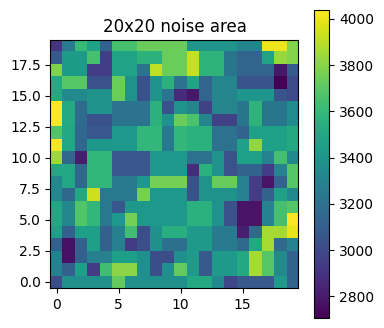

The RMS is the calculated value of: 3376.3627178518605
Mean: 3366.1675
Standard deviation: 262.1861255744667
The std differs from the RMS because the std measures using the mean as the starting point while RMS uses 0 as its starting value
Due to this std is also the better quantifier for noise, since this better distinghuishes between values below and above the mean


In [49]:
#6.3
import numpy as np
import matplotlib.pyplot as plt

noise_slice = dat_float[5:25, 5:25]

rms = np.sqrt(np.mean(noise_slice**2))
noise_mean = np.mean(noise_slice)
noise_std = np.std(noise_slice)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(noise_slice, cmap='viridis', origin='lower')
ax.set_title("20x20 noise area")
fig.colorbar(im)
plt.show()

print(f'The RMS is the calculated value of: {rms}')
print(f"Mean: {noise_mean}")
print(f"Standard deviation: {noise_std}")
print('The std differs from the RMS because the std measures using the mean as the starting point while RMS uses 0 as its starting value')
print('Due to this std is also the better quantifier for noise, since this better distinghuishes between values below and above the mean')

In [51]:
#Question 6.5
import numpy as np
from astropy.io import fits

nm0 = fits.getdata('noisemap0.fits')
nm1 = fits.getdata('noisemap1.fits')
nm2 = fits.getdata('noisemap2.fits')
std0 = np.std(nm0)
std1 = np.std(nm1)
std2 = np.std(nm2)
print(f"STD0: {std0}")
print(f"STD1: {std1}")
print(f"STD2: {std2}")

noisestower = np.stack((nm0, nm1, nm2), axis=0)
rudeimage = np.mean(noisestower, axis=0)
STD = np.std(rudeimage)
print(f"Measured STD: {STD}")

STDT = (1 / 3) * np.sqrt(std0**2 + std1**2 + std2**2)
print(f"Theoretical STD: {STDT}")
print(f'Yes, the measured std and theoretical do indeed match')

STD0: 9.98401556679484
STD1: 10.003955116338458
STD2: 9.995349488722516
Measured STD: 5.773191380233297
Theoretical STD: 5.770294583366139
Yes, the measured std and theoretical do indeed match


In [1]:
#Question 6.6
from astropy.io import fits
import numpy as np
from astropy.table import Table

hdul = fits.open('APOGEE_stars.fits')
data_table = Table(hdul[1].data)

print('When reading an image this returns an array, while reading tables returns a FITS object(basically an array you access the data using the columns name)')
print('An image is an N-dimensional grid, while tables are always 2D with rows and columns')


c1 = data_table['STARFLAG'] == 0
c2 = data_table['ASPCAPFLAG'] == 0
c3 = data_table['SNR'] > 10
c4 = (data_table['GAIAEDR3_PARALLAX'] / data_table['GAIAEDR3_PARALLAX_ERROR']) > 5
c5 = ~np.isnan(data_table['GAIAEDR3_PHOT_G_MEAN_MAG'])
c6 = ~np.isnan(data_table['GAIAEDR3_PHOT_BP_MEAN_MAG'])
c7 = ~np.isnan(data_table['GAIAEDR3_PHOT_RP_MEAN_MAG'])

data_table['DATAFLAG'] = np.where(c1 & c2 & c3 & c4 & c5 & c6 & c7, 1, 0)

m_g = data_table['GAIAEDR3_PHOT_G_MEAN_MAG']
plx = data_table['GAIAEDR3_PARALLAX']

with np.errstate(invalid='ignore'):
    abs_mag = m_g + 5 * np.log10(plx / 1000) + 5

data_table['ABS_MAG_G'] = abs_mag
data_table['ABS_MAG_G'][data_table['DATAFLAG'] == 0] = -1.0

data_table.write('APOGEE_update.fits', overwrite=True)
print(data_table[['DATAFLAG', 'ABS_MAG_G']][:10])
hdul.close()


When reading an image this returns an array, while reading tables returns a FITS object(basically an array you access the data using the columns name)
An image is an N-dimensional grid, while tables are always 2D with rows and columns
DATAFLAG ABS_MAG_G
-------- ---------
       0      -1.0
       0      -1.0
       0      -1.0
       0      -1.0
       1 2.7881603
       0      -1.0
       1 2.9852724
       0      -1.0
       0      -1.0
       0      -1.0


Maximum flux: 
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


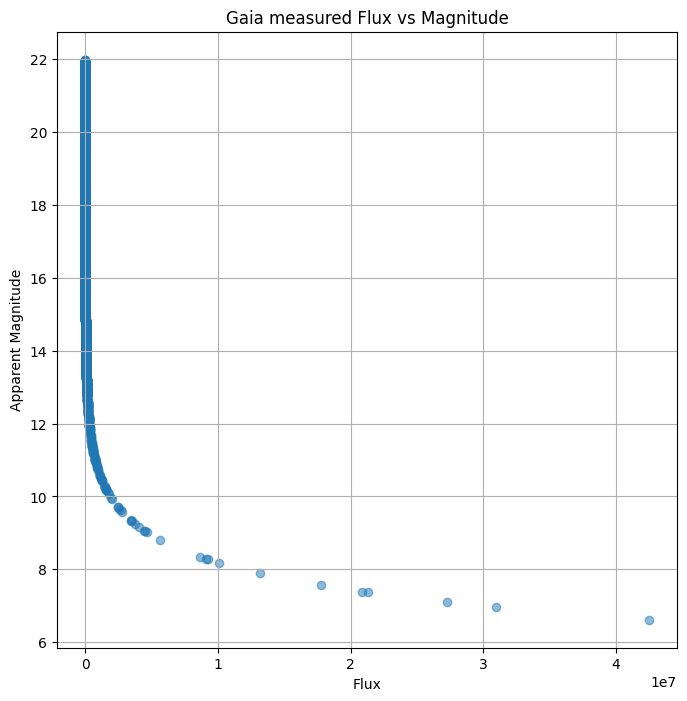

calculated average m0: 25.6884


In [23]:
#Question 6.7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DF = pd.read_csv('gaiaTestData.csv')
maxFlux = DF[DF['phot_g_mean_flux'] == DF['phot_g_mean_flux'].max()]
print('Maximum flux: ')
print(maxFlux)

DF_sort = DF.sort_values('phot_g_mean_flux')

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(DF_sort['phot_g_mean_flux'], DF_sort['phot_g_mean_mag'], alpha=0.5)
ax.set_xlabel('Flux')
ax.set_ylabel('Apparent Magnitude')
ax.set_title('Gaia measured Flux vs Magnitude')
ax.grid(True)
plt.show()

DF['m0_calculated'] = DF['phot_g_mean_mag'] + 2.5 * np.log10(DF['phot_g_mean_flux'])
av_m0 = DF['m0_calculated'].mean()
print(f'calculated average m0: {av_m0:.4f}')

In [30]:
#Question 6.10
from astroquery.gaia import Gaia
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
query = "SELECT TOP 50 source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag FROM gaiadr3.gaia_source WHERE parallax/parallax_error>5 AND phot_g_mean_mag>0 AND phot_bp_mean_mag>0 AND phot_rp_mean_mag>0"
job = Gaia.launch_job(query)
table = job.get_results()
df = table.to_pandas()
table.write('astroquery_gaia.fits', overwrite=True)
print('File created')
data = fits.getdata('astroquery_gaia.fits')
print(data.names)
print(len(data))
print(data[:5])

File created
['SOURCE_ID', 'ra', 'dec', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag']
50
[( 6017249992832, 44.87059951, 0.1724258 , 0.6112394 , 0.09518827, 17.294584, 17.981346, 16.499447)
 ( 6223408420864, 44.93764899, 0.1883934 , 3.09784893, 0.01709176, 13.932565, 14.462439, 13.249663)
 ( 7284264691456, 45.06227669, 0.21600442, 6.22719213, 0.02009976, 14.068443, 14.881823, 13.186197)
 ( 7941395336832, 44.97267889, 0.23783321, 4.56903665, 0.03401984, 15.159093, 16.131428, 14.181014)
 (16355235668608, 45.22894242, 0.38079256, 2.37702226, 0.0950569 , 17.238367, 18.426327, 16.16518 )]


In [49]:
#Question 6.14
import numpy as np

class Fibonacci:
    
    def __init__(self):
        self.a = 0
        self.b = 1
        
    def bolleN(self, n):
        a = self.a
        b = self.b
        for _ in range(2, n):
            a, b = b, a+b
        return b
    
    def watdebal(self, n, m):
        a = self.a
        b = self.b
        resultje=[]
        for _ in range(2, n):
            if b % m == 0:
                resultje.append(b)
            a, b = b, a+b
        return resultje
n=int(input('input n: '))
m=int(input('input m: '))
bibi = Fibonacci()

print(f'The Nth term in the fibonacci sequence: {bibi.bolleN(n)}')
print(f'All terms below the Nth divisible by m: {bibi.watdebal(n, m)}')

input n: 100
input m: 7
The Nth term in the fibonacci sequence: 218922995834555169026
All terms below the Nth divisible by m: [21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
